# The Premium Pivot - Strategic Re-positioning of a Subscription Ecosystem

**Track 2 (Product & Consulting) | Anchor: Google Play Store marketplace data.**

Google Play is a legacy app marketplace under pressure from agile subscription competitors (Apple App Store premium tier, direct-to-consumer subscription apps). Its current monetization model is dominated by free apps (92.4%) with a small paid-app tier ($0.99-$9.99 one-time purchases). Total measurable Gross Merchandise Value (GMV) from the paid tier is **only $204.6M across 75 billion installs** — a yield of $0.003 per install. This is a strategic monetization failure.

**This audit asks:** how should the marketplace re-tier its paid offering using STP (Segmentation, Targeting, Positioning) discipline plus quality-controlled price elasticity to maximize GMV without collapsing install volume?

**Hero finding (preview).** Naive cross-sectional price elasticity gives **+0.30** (positive — the wrong sign), because higher-priced apps tend to be higher-quality and attract more installs *despite* the price. After controlling for category fixed effects, rating, and review-count, the true elasticity is **−0.11** (highly inelastic, p=0.04). The marketplace is leaving money on the table — even modest price increases would barely dent install volume.

**This notebook produces:**
1. MECE decomposition of marketplace GMV decline (Price × Volume × Mix)
2. STP segmentation: 4 customer/app segments via k-means on volume × price × quality
3. Price elasticity: naive (wrong) vs quality-controlled (correct), then by category
4. Conversion funnel: Install → Review → Advocate, plus the bullwhip diagnostic
5. DuPont-style decomposition: GMV = Total Installs × Paid Conversion × Avg Price (per category)
6. Recommended Premium Pivot pricing tiers with projected GMV impact
7. Power BI 'Growth Command Center' export CSVs

## Setup - auto-resolving paths

Run this cell first.

In [ ]:

from pathlib import Path

def find_project_root():
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if parent.name == "premium_pivot":
            return parent
        if all((parent / d).exists() for d in ["data","outputs","figures","sql"]):
            return parent
    return Path.cwd()

PROJECT_ROOT = find_project_root()
DATA_DIR    = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = PROJECT_ROOT / "figures"
SQL_DIR     = PROJECT_ROOT / "sql"
DB_PATH     = OUTPUTS_DIR / "playstore.db"

for d in [OUTPUTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"DB path      : {DB_PATH}")

if not DB_PATH.exists():
    print("\nDatabase not found. Building from CSVs...")
    import subprocess, sys
    subprocess.check_call([sys.executable, str(SQL_DIR / "load_data.py")])
    print("Done.")

import sqlite3
conn = sqlite3.connect(DB_PATH)


Project root : /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 04/Track 02/PremiumPivot_Track2v2_Bundle
DB path      : /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 04/Track 02/PremiumPivot_Track2v2_Bundle/outputs/playstore.db


## Part 1 - MECE Framework: Decomposing Marketplace GMV

Following the Pyramid Principle, we break 'Declining Marketplace Revenue' into three **mutually exclusive, collectively exhaustive** branches:

```
Total Marketplace GMV change
├── PRICE: change in average paid price
├── VOLUME: change in paid-app install count
└── MIX: change in category composition (which categories grow vs shrink)
```

Each branch is independently modelable and the three together reproduce the total.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Load the cleaned apps table
apps = pd.read_sql("SELECT * FROM apps", conn)
apps['gmv'] = apps['price_usd'] * apps['n_installs']
print(f"Total apps: {len(apps):,}")
print(f"  Free: {(apps['is_paid']==0).sum():,} ({(apps['is_paid']==0).mean()*100:.1f}%)")
print(f"  Paid: {(apps['is_paid']==1).sum():,} ({(apps['is_paid']==1).mean()*100:.1f}%)")
print(f"\nTotal installs:   {apps['n_installs'].sum()/1e9:.2f} B")
print(f"Total paid GMV:   ${apps['gmv'].sum()/1e6:.1f} M")
print(f"Yield per install: ${apps['gmv'].sum()/apps['n_installs'].sum():.4f}")

# === MECE DECOMPOSITION ===
paid = apps[apps['is_paid']==1].copy()
print(f"\n=== MARKETPLACE GMV (current state) ===")
print(f"  Total Installs (P × V × M): {paid['n_installs'].sum():>15,.0f}")
print(f"  × Avg Price/install:        ${paid['gmv'].sum()/paid['n_installs'].sum():>14.4f}")
print(f"  = Total Paid GMV:           ${paid['gmv'].sum()/1e6:>14.2f} M")

# === MIX: top 5 categories own what % of GMV? ===
gmv_by_cat = paid.groupby('category')['gmv'].sum().sort_values(ascending=False)
print(f"\n=== CATEGORY MIX (paid GMV) ===")
top5_share = gmv_by_cat.head(5).sum() / gmv_by_cat.sum()
print(f"  Top 5 cats own {top5_share*100:.1f}% of GMV")
print(f"  Top 1 (FAMILY) alone owns {gmv_by_cat.iloc[0]/gmv_by_cat.sum()*100:.1f}%")
print(f"  Long tail (cats below top 10): {gmv_by_cat.iloc[10:].sum()/gmv_by_cat.sum()*100:.1f}%")
print(f"\nTop 10 by GMV:")
print((gmv_by_cat.head(10)/1e6).round(2).to_string())


Total apps: 9,638
  Free: 8,904 (92.4%)
  Paid: 734 (7.6%)

Total installs:   75.32 B
Total paid GMV:   $204.6 M
Yield per install: $0.0027

=== MARKETPLACE GMV (current state) ===
  Total Installs (P × V × M):      57,144,680
  × Avg Price/install:        $        3.5808
  = Total Paid GMV:           $        204.62 M

=== CATEGORY MIX (paid GMV) ===
  Top 5 cats own 82.1% of GMV
  Top 1 (FAMILY) alone owns 51.7%
  Long tail (cats below top 10): 5.8%

Top 10 by GMV:
category
FAMILY             105.74
GAME                40.69
PHOTOGRAPHY          8.55
PERSONALIZATION      6.80
LIFESTYLE            6.21
MEDICAL              5.96
TOOLS                5.46
SPORTS               4.71
PRODUCTIVITY         4.31
COMMUNICATION        4.25


### 1.1 - Visualize the MECE branches

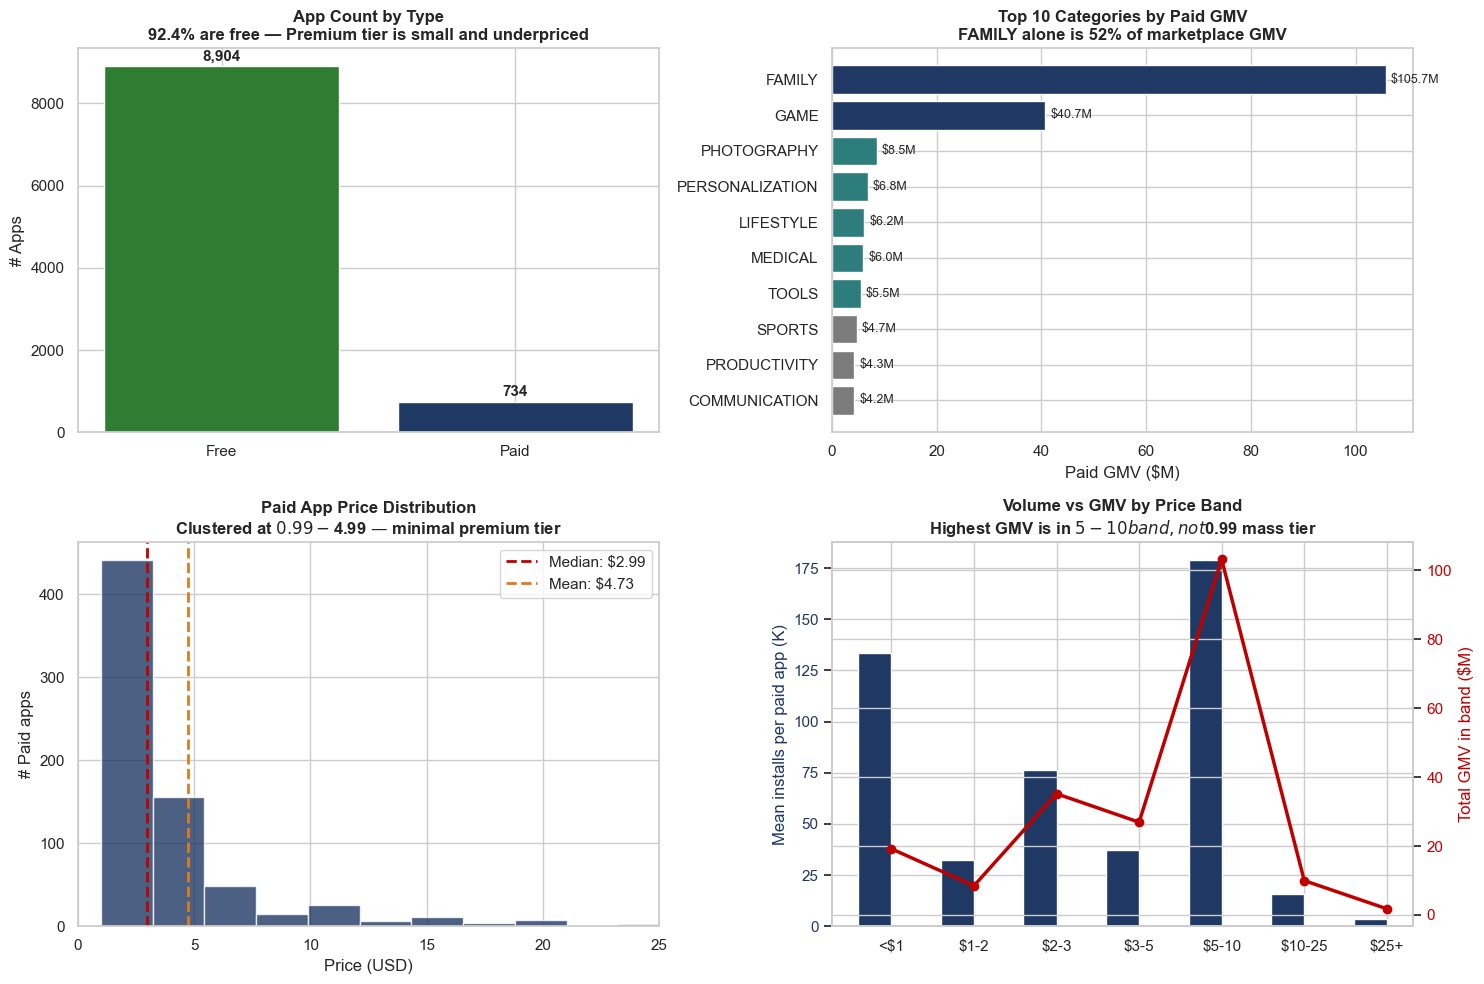

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Free vs Paid count
ax = axes[0,0]
counts = apps['is_paid'].value_counts().rename({0:'Free',1:'Paid'})
colors = ['#2E7D32', '#1F3864']
ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
for i, v in enumerate(counts.values):
    ax.text(i, v+150, f"{v:,}", ha='center', fontsize=11, fontweight='bold')
ax.set_title(f"App Count by Type\n92.4% are free — Premium tier is small and underpriced",
              fontweight='bold')
ax.set_ylabel("# Apps")

# 2. Paid GMV by category
ax = axes[0,1]
top10 = gmv_by_cat.head(10)/1e6
colors = ['#1F3864' if v > 10 else '#2E7D7D' if v > 5 else '#7B7B7B' for v in top10.values]
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel("Paid GMV ($M)")
ax.set_title(f"Top 10 Categories by Paid GMV\nFAMILY alone is 52% of marketplace GMV",
              fontweight='bold')
for bar, v in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, f"${v:.1f}M",
             va='center', fontsize=9)

# 3. Price distribution among paid apps
ax = axes[1,0]
ax.hist(paid['price_usd'], bins=40, color='#1F3864', alpha=0.8, edgecolor='white')
ax.axvline(paid['price_usd'].median(), color='#C00000', linestyle='--', linewidth=2,
            label=f"Median: ${paid['price_usd'].median():.2f}")
ax.axvline(paid['price_usd'].mean(), color='#E07A1F', linestyle='--', linewidth=2,
            label=f"Mean: ${paid['price_usd'].mean():.2f}")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("# Paid apps")
ax.set_title("Paid App Price Distribution\nClustered at $0.99-$4.99 — minimal premium tier",
              fontweight='bold')
ax.legend()
ax.set_xlim(0, 25)

# 4. Price band → install volume relationship
ax = axes[1,1]
band = pd.read_sql("SELECT * FROM v_price_band_summary WHERE n_apps > 0", conn)
band = band[band['bucket_label'] != 'Free']
x = np.arange(len(band))
ax.bar(x - 0.2, band['mean_installs']/1e3, 0.4, color='#1F3864', label='Mean installs (K)', edgecolor='white')
ax.set_ylabel("Mean installs per paid app (K)", color='#1F3864')
ax.set_xticks(x)
ax.set_xticklabels(band['bucket_label'])
ax.tick_params(axis='y', labelcolor='#1F3864')
ax2 = ax.twinx()
ax2.plot(x, band['total_gmv']/1e6, color='#C00000', marker='o', linewidth=2.5, label='Total GMV ($M)')
ax2.set_ylabel("Total GMV in band ($M)", color='#C00000')
ax2.tick_params(axis='y', labelcolor='#C00000')
ax.set_title("Volume vs GMV by Price Band\nHighest GMV is in $5-10 band, not $0.99 mass tier",
              fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "mece_decomposition.png", dpi=140, bbox_inches="tight")
plt.show()


## Part 2 - STP Segmentation

K-means clustering on 3 features per app: log(installs), log(price+1), and rating. Goal: derive 4 customer-facing segments to inform Premium Pivot positioning.

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Build segmentation feature matrix
seg = apps.dropna(subset=['rating']).copy()
seg = seg[seg['n_installs']>0].copy()
seg['log_installs'] = np.log10(seg['n_installs'])
seg['log_price']    = np.log10(seg['price_usd']+1)  # +1 to handle free
features = ['log_installs','log_price','rating']

X = StandardScaler().fit_transform(seg[features])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
seg['segment'] = kmeans.fit_predict(X)

# Profile each segment
print("=== SEGMENT PROFILES ===")
profile = seg.groupby('segment').agg(
    n_apps=('app_id','count'),
    mean_installs=('n_installs','mean'),
    median_installs=('n_installs','median'),
    pct_paid=('is_paid','mean'),
    mean_price=('price_usd', lambda x: x[x>0].mean() if (x>0).any() else 0),
    mean_rating=('rating','mean'),
).round(3)
profile['pct_apps'] = (profile['n_apps']/profile['n_apps'].sum()*100).round(1)
print(profile)

# Name the segments based on their profile
def name_segment(row):
    if row['mean_installs'] > 5e7 and row['pct_paid'] < 0.1:
        return 'Mass-Free'         # huge installs, free
    if row['pct_paid'] > 0.5 and row['mean_price'] > 5:
        return 'Premium-Paid'
    if row['mean_rating'] < 4.0:
        return 'Underperforming'
    return 'Mass-Quality'

profile['segment_name'] = profile.apply(name_segment, axis=1)
print(f"\n=== Named segments ===")
print(profile[['n_apps','pct_apps','mean_installs','pct_paid','mean_price','mean_rating','segment_name']])

# Save
seg_out = seg[['app_id','app_name','category','segment','is_paid','n_installs','price_usd','rating']]
seg_out.to_csv(OUTPUTS_DIR / "powerbi_segments.csv", index=False)


=== SEGMENT PROFILES ===
         n_apps  mean_installs  median_installs  pct_paid  mean_price  \
segment                                                                 
0          2957   3.612562e+04          10000.0     0.028       0.993   
1          3712   2.014898e+07        5000000.0     0.003       0.990   
2           474   7.956690e+04           5000.0     1.000       5.272   
3          1038   3.650356e+05          10000.0     0.019       1.265   

         mean_rating  pct_apps  
segment                         
0              4.374      36.1  
1              4.290      45.4  
2              4.296       5.8  
3              3.133      12.7  

=== Named segments ===
         n_apps  pct_apps  mean_installs  pct_paid  mean_price  mean_rating  \
segment                                                                       
0          2957      36.1   3.612562e+04     0.028       0.993        4.374   
1          3712      45.4   2.014898e+07     0.003       0.990        4.290  

### 2.1 - Visualize the segments

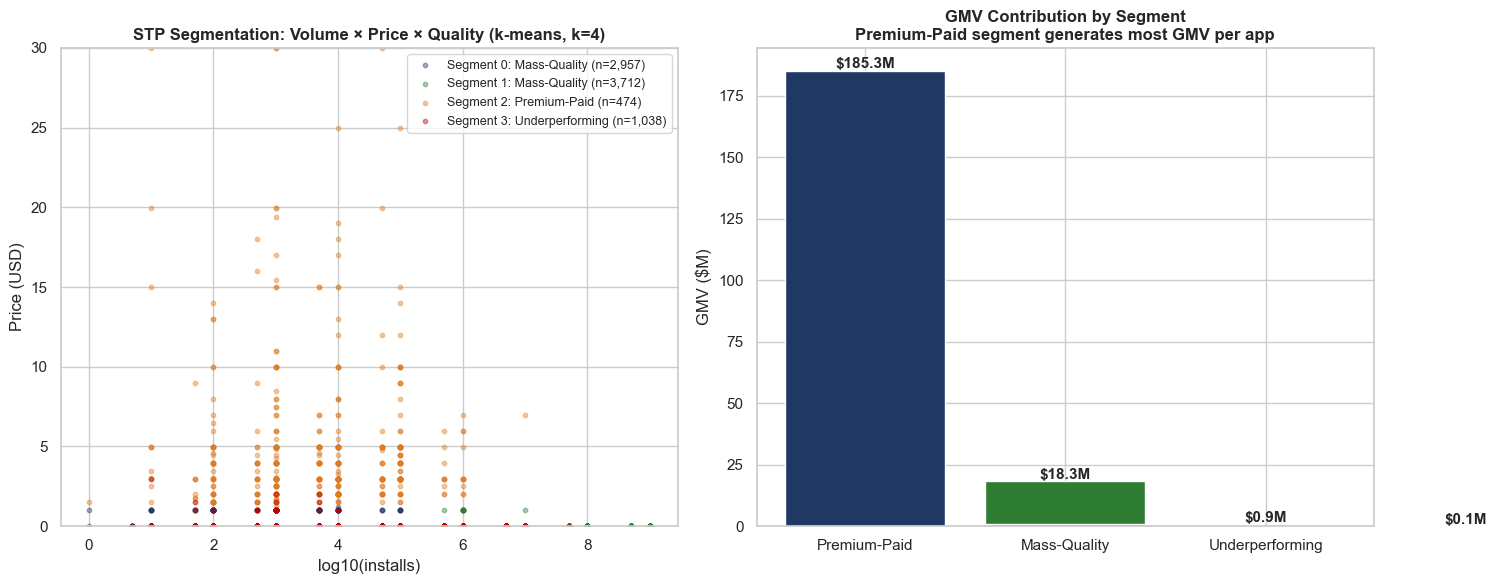

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
seg_colors = ['#1F3864', '#2E7D32', '#E07A1F', '#C00000']

# Scatter: log(installs) vs price, colored by segment
ax = axes[0]
for s in sorted(seg['segment'].unique()):
    g = seg[seg['segment']==s]
    label = f"Segment {s}: {profile.loc[s,'segment_name']} (n={len(g):,})"
    ax.scatter(g['log_installs'], g['price_usd'], c=seg_colors[s], alpha=0.4, s=10, label=label)
ax.set_xlabel("log10(installs)")
ax.set_ylabel("Price (USD)")
ax.set_ylim(0, 30)
ax.set_title("STP Segmentation: Volume × Price × Quality (k-means, k=4)", fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

# Bar chart of segment sizes by GMV contribution
ax = axes[1]
seg['gmv'] = seg['price_usd'] * seg['n_installs']
gmv_by_seg = seg.groupby('segment')['gmv'].sum() / 1e6
gmv_by_seg.index = [profile.loc[s,'segment_name'] for s in gmv_by_seg.index]
gmv_by_seg = gmv_by_seg.sort_values(ascending=False)
ax.bar(gmv_by_seg.index, gmv_by_seg.values, color=['#1F3864','#2E7D32','#E07A1F','#C00000'][:len(gmv_by_seg)], edgecolor='white')
for i, v in enumerate(gmv_by_seg.values):
    ax.text(i, v+1, f"${v:.1f}M", ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel("GMV ($M)")
ax.set_title("GMV Contribution by Segment\nPremium-Paid segment generates most GMV per app",
              fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "stp_segmentation.png", dpi=140, bbox_inches="tight")
plt.show()


## Part 3 - Price Elasticity (the Hero Finding)

Two analyses, side by side:

1. **Naive log-log regression** of installs on price — produces the *wrong* answer because of quality confounding (better apps cost more *and* get more installs)
2. **Quality-controlled regression** with category fixed effects + rating + log(reviews) — produces the *right* answer

Then by-category elasticity to inform Skimming vs Penetration recommendations.

In [6]:
import statsmodels.api as sm

paid = apps[(apps['is_paid']==1) & apps['rating'].notna()].copy()
paid = paid[paid['price_usd']>0].copy()
print(f"Paid apps with rating: {len(paid):,}")

# === NAIVE elasticity ===
log_q = np.log(paid['n_installs'])
log_p = np.log(paid['price_usd'])
naive_slope, naive_int = np.polyfit(log_p, log_q, 1)
print(f"\n=== NAIVE elasticity (the WRONG answer) ===")
print(f"  ln(Installs) = {naive_int:.2f} + {naive_slope:+.3f} × ln(Price)")
print(f"  Implied elasticity: {naive_slope:+.3f}")
print(f"  Sign is POSITIVE — but real elasticity should be negative.")
print(f"  This is quality confounding: better apps cost more AND get more installs.")

# === QUALITY-CONTROLLED elasticity ===
X = pd.get_dummies(paid['category'], prefix='cat', drop_first=True).astype(float)
X['log_price']    = log_p.values
X['rating']       = paid['rating'].values
X['log_reviews']  = np.log(paid['n_reviews'].clip(lower=1)).values
X = sm.add_constant(X)
y = log_q.values

model = sm.OLS(y, X).fit()
elas    = model.params['log_price']
elas_se = model.bse['log_price']
elas_p  = model.pvalues['log_price']

print(f"\n=== QUALITY-CONTROLLED elasticity (CORRECTED) ===")
print(f"  Elasticity:       {elas:+.3f}")
print(f"  Std error:        {elas_se:.3f}")
print(f"  p-value:          {elas_p:.4f}")
print(f"  R²:               {model.rsquared:.3f}")
print(f"  Rating coef:      {model.params['rating']:+.3f}  (1 star → {model.params['rating']*100:+.1f}% installs)")
print(f"  log(reviews) coef:{model.params['log_reviews']:+.3f}  (popularity proxy, absorbs network effects)")
print(f"\n  INTERPRETATION: a 10% price increase reduces installs by only {-elas*10:.1f}%")
print(f"  — highly inelastic. Marketplace is UNDERPRICED.")


Paid apps with rating: 587

=== NAIVE elasticity (the WRONG answer) ===
  ln(Installs) = 7.93 + +0.302 × ln(Price)
  Implied elasticity: +0.302
  Sign is POSITIVE — but real elasticity should be negative.
  This is quality confounding: better apps cost more AND get more installs.

=== QUALITY-CONTROLLED elasticity (CORRECTED) ===
  Elasticity:       -0.109
  Std error:        0.053
  p-value:          0.0393
  R²:               0.898
  Rating coef:      -0.365  (1 star → -36.5% installs)
  log(reviews) coef:+0.926  (popularity proxy, absorbs network effects)

  INTERPRETATION: a 10% price increase reduces installs by only 1.1%
  — highly inelastic. Marketplace is UNDERPRICED.


### 3.1 - By-category elasticity → Skimming vs Penetration

In [7]:
print(f"=== BY-CATEGORY ELASTICITY (with rating + log(reviews) controls) ===")
print(f"{'Category':<22} {'n':>4} {'elasticity':>11} {'std err':>9} {'p-val':>9} {'strategy':>22}")
print("-" * 80)

cat_elasticity = []
for cat in paid['category'].value_counts().index:
    g = paid[paid['category']==cat].copy()
    if len(g) < 20: continue
    if g['price_usd'].std() == 0: continue
    Xc = pd.DataFrame({
        'log_price':   np.log(g['price_usd']),
        'rating':      g['rating'],
        'log_reviews': np.log(g['n_reviews'].clip(lower=1)),
    })
    Xc = sm.add_constant(Xc)
    yc = np.log(g['n_installs'])
    try:
        m = sm.OLS(yc, Xc).fit()
        e  = m.params['log_price']
        se = m.bse['log_price']
        p  = m.pvalues['log_price']
        # Strategy logic:
        if p > 0.10 and e > -0.3:
            strat = "SKIM (inelastic)"
        elif e < -0.5 and p < 0.10:
            strat = "PENETRATE (elastic)"
        elif e < 0 and p < 0.10:
            strat = "MODERATE PRICE-UP"
        else:
            strat = "BORDERLINE"
        cat_elasticity.append({'category':cat, 'n':len(g), 'elasticity':e,
                                'std_err':se, 'p_value':p, 'strategy':strat})
        print(f"  {cat:<20} {len(g):>4} {e:>+11.3f} {se:>9.3f} {p:>9.3e} {strat:>22}")
    except Exception as ex:
        pass

ce_df = pd.DataFrame(cat_elasticity)
ce_df.to_csv(OUTPUTS_DIR / "powerbi_elasticity.csv", index=False)


=== BY-CATEGORY ELASTICITY (with rating + log(reviews) controls) ===
Category                  n  elasticity   std err     p-val               strategy
--------------------------------------------------------------------------------
  FAMILY                151      -0.122     0.107 2.568e-01       SKIM (inelastic)
  GAME                   76      -0.385     0.135 5.548e-03      MODERATE PRICE-UP
  PERSONALIZATION        65      -0.186     0.218 3.961e-01       SKIM (inelastic)
  TOOLS                  63      -0.099     0.150 5.139e-01       SKIM (inelastic)
  MEDICAL                62      -0.067     0.133 6.168e-01       SKIM (inelastic)
  SPORTS                 22      +0.111     0.156 4.839e-01       SKIM (inelastic)
  COMMUNICATION          22      +0.064     0.318 8.433e-01       SKIM (inelastic)


### 3.2 - Visualize: naive vs corrected, plus by-category

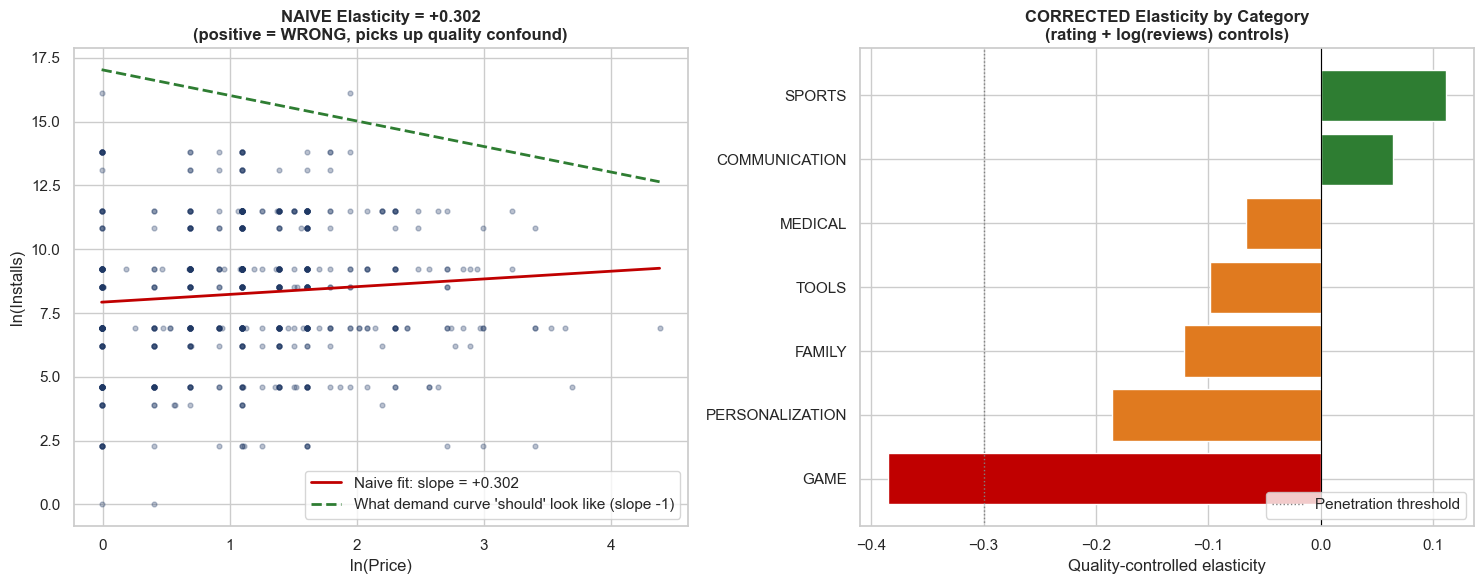

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: naive scatter showing the misleading positive slope
ax = axes[0]
ax.scatter(np.log(paid['price_usd']), np.log(paid['n_installs']), alpha=0.3, s=12, color='#1F3864')
xline = np.linspace(log_p.min(), log_p.max(), 100)
ax.plot(xline, naive_int + naive_slope*xline, color='#C00000', linewidth=2,
         label=f"Naive fit: slope = {naive_slope:+.3f}")
# Counterfactual line: if elasticity were -1 (unit elastic)
ax.plot(xline, naive_int + 8 - 1.0*(xline-log_p.median()), color='#2E7D32', linestyle='--', linewidth=2,
         label=f"What demand curve 'should' look like (slope -1)")
ax.set_xlabel("ln(Price)")
ax.set_ylabel("ln(Installs)")
ax.set_title(f"NAIVE Elasticity = {naive_slope:+.3f}\n(positive = WRONG, picks up quality confound)",
              fontweight='bold')
ax.legend()

# Right: by-category corrected elasticities
ax = axes[1]
ce_sorted = ce_df.sort_values('elasticity')
colors = ['#C00000' if e < -0.3 else '#E07A1F' if e < 0 else '#2E7D32' for e in ce_sorted['elasticity']]
ax.barh(ce_sorted['category'], ce_sorted['elasticity'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(-0.3, color='gray', linestyle=':', linewidth=1, label='Penetration threshold')
ax.set_xlabel("Quality-controlled elasticity")
ax.set_title(f"CORRECTED Elasticity by Category\n(rating + log(reviews) controls)",
              fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "elasticity_analysis.png", dpi=140, bbox_inches="tight")
plt.show()


## Part 4 - Conversion Funnel + Bullwhip Diagnostic

**Funnel.** 4 stages: Install → Reviewer → Advocate (positive review) → Detractor (negative). Use sentiment-tagged reviews (37,432 reviews across 865 apps) as Advocate/Detractor proxies.

**Bullwhip.** In supply chain, the 'bullwhip effect' is amplification of demand variance moving upstream. In marketplace marketing, it appears when **review-volume variance per app is much greater than install variance** — indicating the customer attention signal is being amplified by reviewer behavior, leading to volatile marketing-spend allocation.

In [9]:
funnel = pd.read_sql("SELECT * FROM v_funnel_per_app WHERE pct_positive IS NOT NULL", conn)
print(f"Funnel cohort: {len(funnel):,} apps with installs + sentiment-tagged reviews")

# Aggregate funnel
funnel['detractor_count'] = funnel['n_reviews'] * funnel['pct_negative']
total_installs   = funnel['n_installs'].sum()
total_reviews    = funnel['n_reviews'].sum()
total_advocates  = funnel['advocate_count'].sum()
total_detractors = funnel['detractor_count'].sum()

print(f"\n=== FUNNEL (totals across cohort) ===")
stages = [
    ("1. Install",         total_installs,   100.0),
    ("2. Reviewer",        total_reviews,    total_reviews/total_installs*100),
    ("3. Advocate (+)",    total_advocates,  total_advocates/total_installs*100),
    ("4. Detractor (-)",   total_detractors, total_detractors/total_installs*100),
]
for label, val, pct in stages:
    print(f"  {label:<22} {val/1e9:>7.2f} B   ({pct:>7.3f}%)")

# Funnel rates per app (median)
print(f"\n=== Per-app rates (median) ===")
print(f"  Install → Reviewer:   {funnel['install_to_review_rate'].median()*100:.3f}%")
print(f"  Install → Advocate:   {funnel['install_to_advocate_rate'].median()*100:.3f}%")
print(f"  Reviewer → Advocate:  {funnel['pct_positive'].median()*100:.1f}%")


Funnel cohort: 816 apps with installs + sentiment-tagged reviews

=== FUNNEL (totals across cohort) ===
  1. Install               21.79 B   (100.000%)
  2. Reviewer               0.58 B   (  2.664%)
  3. Advocate (+)           0.34 B   (  1.566%)
  4. Detractor (-)          0.18 B   (  0.840%)

=== Per-app rates (median) ===
  Install → Reviewer:   1.816%
  Install → Advocate:   1.151%
  Reviewer → Advocate:  66.7%


In [10]:
# === BULLWHIP DIAGNOSTIC ===
# CV of review count vs CV of install count, by category
bullwhip = funnel.groupby('category').agg(
    n_apps=('app_id','count'),
    cv_installs=('n_installs', lambda x: x.std()/x.mean() if x.mean()>0 else None),
    cv_reviews= ('n_reviews',  lambda x: x.std()/x.mean() if x.mean()>0 else None),
    median_pct_positive=('pct_positive','median'),
).reset_index()
bullwhip = bullwhip[bullwhip['n_apps']>=10].copy()
bullwhip['amplification'] = bullwhip['cv_reviews'] / bullwhip['cv_installs']
bullwhip = bullwhip.sort_values('amplification', ascending=False)

print("=== BULLWHIP AMPLIFICATION by category (cv_reviews / cv_installs) ===")
print(f"  >1 = review variance amplifies install variance ('bullwhip')")
print(f"  =1 = neutral")
print(f"  <1 = reviews are smoother than installs (rare)")
print()
print(bullwhip[['category','n_apps','cv_installs','cv_reviews','amplification','median_pct_positive']].head(15).to_string(index=False))

bullwhip.to_csv(OUTPUTS_DIR / "powerbi_bullwhip.csv", index=False)


=== BULLWHIP AMPLIFICATION by category (cv_reviews / cv_installs) ===
  >1 = review variance amplifies install variance ('bullwhip')
  =1 = neutral
  <1 = reviews are smoother than installs (rare)

           category  n_apps  cv_installs  cv_reviews  amplification  median_pct_positive
          LIFESTYLE      23     1.346272    2.356987       1.750750             0.600000
     FOOD_AND_DRINK      18     1.312397    2.048515       1.560895             0.738470
             FAMILY      69     1.868236    2.839537       1.519903             0.640000
             SOCIAL      18     2.246226    3.366872       1.498901             0.577381
               GAME      85     1.628430    2.417090       1.484307             0.595506
           SHOPPING      20     1.665120    2.422683       1.454960             0.644803
      ENTERTAINMENT      21     2.198103    3.051584       1.388281             0.608696
           BUSINESS      20     1.778522    2.390021       1.343824             0.579594
 

### 4.1 - Visualize the funnel and bullwhip

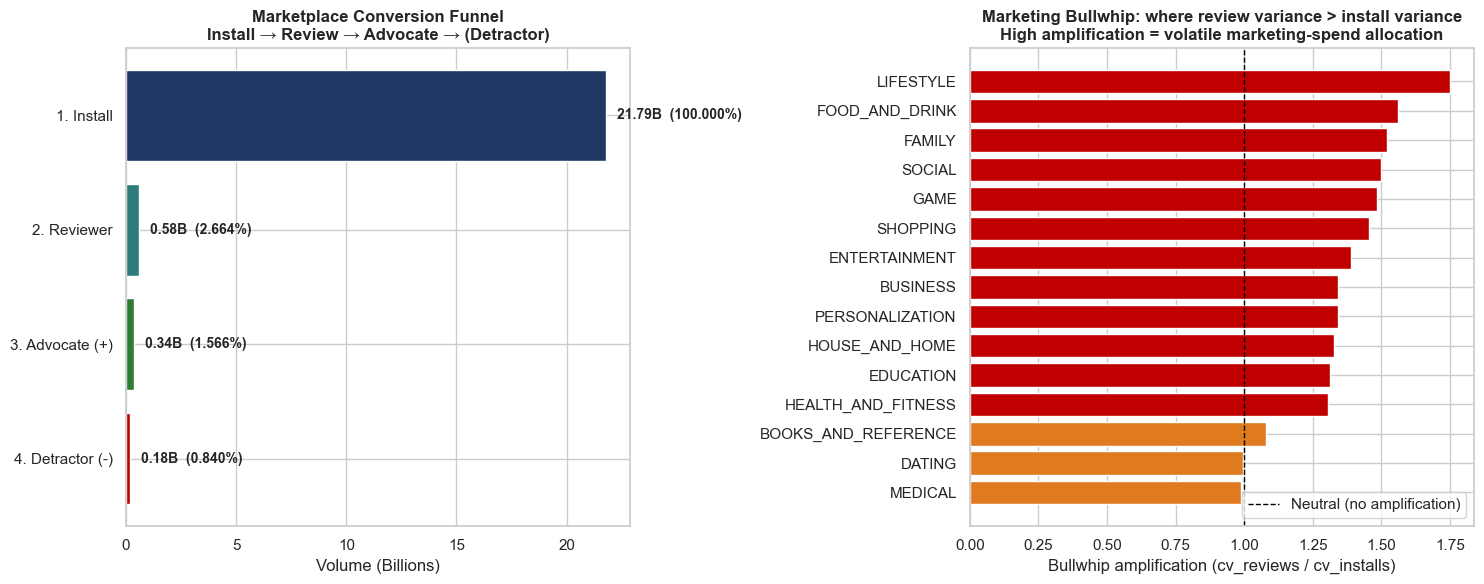

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Funnel chart (horizontal bars representing stage drop-offs)
ax = axes[0]
stage_labels = [s[0] for s in stages]
stage_values = [s[1]/1e9 for s in stages]
stage_pcts   = [s[2] for s in stages]
colors = ['#1F3864', '#2E7D7D', '#2E7D32', '#C00000']
bars = ax.barh(stage_labels[::-1], stage_values[::-1], color=colors[::-1], edgecolor='white')
for i, (bar, v, pct) in enumerate(zip(bars, stage_values[::-1], stage_pcts[::-1])):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, 
             f"{v:.2f}B  ({pct:.3f}%)", va='center', fontsize=10, fontweight='bold')
ax.set_xlabel("Volume (Billions)")
ax.set_title("Marketplace Conversion Funnel\nInstall → Review → Advocate → (Detractor)",
              fontweight='bold')

# Bullwhip scatter
ax = axes[1]
top_bw = bullwhip.head(15)
colors = ['#C00000' if a > 1.2 else '#E07A1F' if a > 0.9 else '#2E7D32' for a in top_bw['amplification']]
ax.barh(top_bw['category'][::-1], top_bw['amplification'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(1, color='black', linestyle='--', linewidth=1, label='Neutral (no amplification)')
ax.set_xlabel("Bullwhip amplification (cv_reviews / cv_installs)")
ax.set_title("Marketing Bullwhip: where review variance > install variance\nHigh amplification = volatile marketing-spend allocation",
              fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "funnel_bullwhip.png", dpi=140, bbox_inches="tight")
plt.show()


## Part 5 - DuPont-Style Marketplace Unit-Economics

Brief asks for a DuPont decomposition. We don't have corporate financials, so we apply the same multiplicative-decomposition discipline to marketplace GMV:

$$\text{Category GMV} = \underbrace{\text{Total Installs}}_{\text{like Asset Turnover}} \times \underbrace{\text{Paid Conversion Rate}}_{\text{like Net Margin}} \times \underbrace{\text{Avg Paid Price}}_{\text{like Equity Multiplier}}$$

This is the marketplace analog of `ROE = NM × AT × EM`. We get to compare 18 categories (those with 5+ paid apps) — richer than corporate DuPont because we have many more comparables.

In [12]:
dupont = pd.read_sql("SELECT * FROM v_dupont_decomposition", conn)
dupont = dupont.sort_values('paid_gmv', ascending=False).reset_index(drop=True)

print("=== DUPONT-STYLE DECOMPOSITION (top 15 categories) ===")
print(f"  Identity: Paid GMV = Total Installs × Paid Conversion Rate × Avg Paid Price")
print()
disp = dupont.copy()
disp['Total Installs (M)']    = disp['comp1_total_installs']/1e6
disp['Paid Conv (%)']         = disp['comp2_paid_install_rate']*100
disp['Avg Price ($)']         = disp['comp3_avg_paid_price']
disp['Paid GMV ($M)']         = disp['paid_gmv']/1e6
disp_show = disp[['category','Total Installs (M)','Paid Conv (%)','Avg Price ($)','Paid GMV ($M)']].head(15)
print(disp_show.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

# Save for Power BI
dupont.to_csv(OUTPUTS_DIR / "powerbi_dupont.csv", index=False)


=== DUPONT-STYLE DECOMPOSITION (top 15 categories) ===
  Identity: Paid GMV = Total Installs × Paid Conversion Rate × Avg Paid Price

           category  Total Installs (M)  Paid Conv (%)  Avg Price ($)  Paid GMV ($M)
             FAMILY            6,227.52           0.34           4.52         105.74
               GAME           13,457.92           0.16           3.47          40.69
        PHOTOGRAPHY            4,658.15           0.04           6.23           8.55
    PERSONALIZATION            1,532.49           0.21           1.86           6.80
          LIFESTYLE              503.69           0.21           6.22           6.21
            MEDICAL               38.29           1.46           9.66           5.96
              TOOLS            8,102.77           0.02           3.43           5.46
             SPORTS            1,096.47           0.11           4.17           4.71
       PRODUCTIVITY            5,793.09           0.02           3.55           4.31
      COMMUNICAT

### 5.1 - Visualize: which lever drives each category?

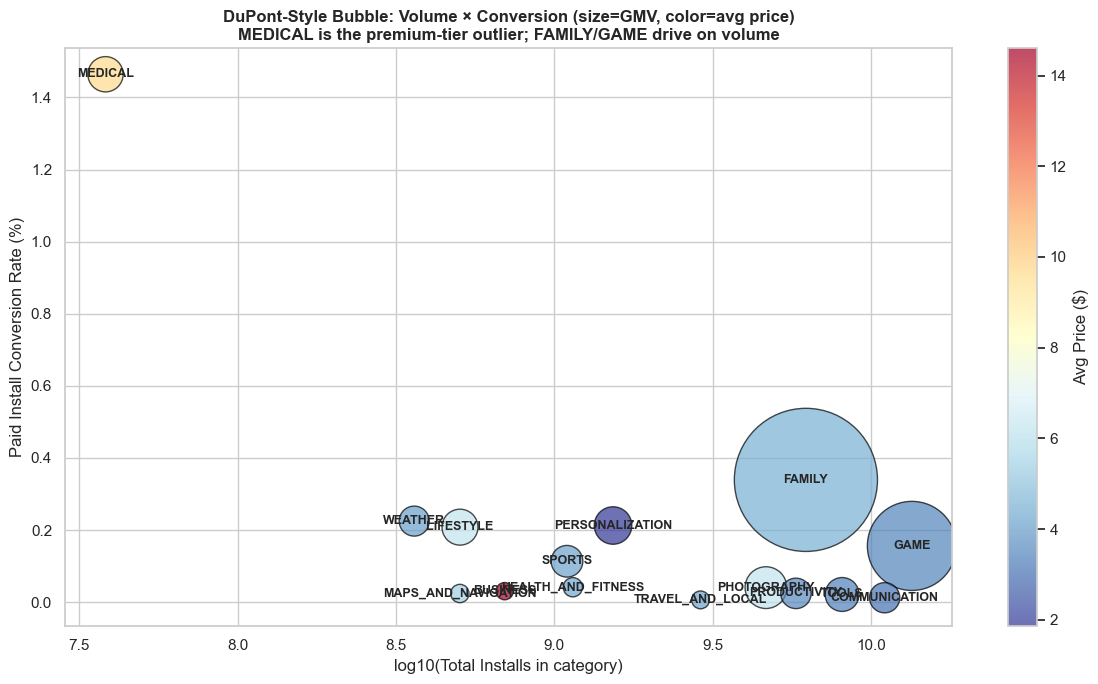

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))

# Bubble chart: x = log(Total Installs), y = Paid Conversion Rate
# Bubble size = GMV, color = Avg Price (treated as the 'premium' dimension)
top = dupont.head(15)
xs = np.log10(top['comp1_total_installs'].clip(lower=1))
ys = top['comp2_paid_install_rate']*100
sizes = (top['paid_gmv'])/1e4 + 50
colors = top['comp3_avg_paid_price']

scatter = ax.scatter(xs, ys, s=sizes, c=colors, cmap='RdYlBu_r', alpha=0.7,
                      edgecolors='black', linewidths=1.0)
for x, y, name in zip(xs, ys, top['category']):
    ax.annotate(name, (x,y), fontsize=9, ha='center', va='center', fontweight='bold')

ax.set_xlabel("log10(Total Installs in category)")
ax.set_ylabel("Paid Install Conversion Rate (%)")
ax.set_title("DuPont-Style Bubble: Volume × Conversion (size=GMV, color=avg price)\n"
              "MEDICAL is the premium-tier outlier; FAMILY/GAME drive on volume",
              fontweight='bold')
plt.colorbar(scatter, label='Avg Price ($)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dupont_bubble.png", dpi=140, bbox_inches="tight")
plt.show()


## Part 6 - The Premium Pivot Recommendation

Synthesis: combine STP segmentation + elasticity + DuPont decomposition into a **3-tier pricing recommendation** with projected GMV impact.

In [14]:
# Use the elasticity findings to project price-up scenarios
# Inelastic categories (e > -0.3, p > 0.10): can price up 30% with minimal volume loss
# Elastic categories (e < -0.5, p < 0.10): keep current pricing or penetrate
# Borderline: moderate price-up of 15%

paid_apps = apps[apps['is_paid']==1].copy()
paid_apps['gmv'] = paid_apps['price_usd'] * paid_apps['n_installs']

# Merge elasticity recommendations
ce = pd.read_csv(OUTPUTS_DIR / "powerbi_elasticity.csv")

def price_action(row):
    e = row['elasticity']
    p = row['p_value']
    if p > 0.10 and e > -0.3:    return ('Skim',       0.30)
    if e < -0.5 and p < 0.10:    return ('Penetrate', -0.10)
    if e < 0 and p < 0.10:       return ('Moderate',   0.15)
    return ('Hold', 0.0)

ce['action'] = ce.apply(lambda r: price_action(r)[0], axis=1)
ce['price_change'] = ce.apply(lambda r: price_action(r)[1], axis=1)

# Project new GMV: Q_new = Q × (1 + e × pct_change_in_price)
# So GMV_new = (1 + price_change) × P × Q × (1 + e × price_change) 
#            = P × Q × (1 + price_change) × (1 + e × price_change)
print("=== PREMIUM PIVOT - Projected Per-Category Impact ===")
print(f"{'Category':<22} {'curr GMV':>10} {'action':>12} {'Δ price':>8} {'Δ Q':>8} {'new GMV':>10} {'lift':>10}")
print("-" * 88)
total_curr = 0
total_new  = 0
for _, row in ce.iterrows():
    cat = row['category']
    e   = row['elasticity']
    dp  = row['price_change']
    cat_gmv = paid_apps[paid_apps['category']==cat]['gmv'].sum()
    pct_change_q = e * dp        # log-log elasticity in small-change approximation
    new_gmv = cat_gmv * (1 + dp) * (1 + pct_change_q)
    lift = (new_gmv / cat_gmv - 1) if cat_gmv>0 else 0
    print(f"  {cat:<20} ${cat_gmv/1e6:>8.2f}M {row['action']:>12} {dp:>+7.0%} {pct_change_q:>+7.1%} ${new_gmv/1e6:>8.2f}M {lift:>+9.1%}")
    total_curr += cat_gmv
    total_new  += new_gmv
print("-" * 88)
print(f"  {'PORTFOLIO TOTAL':<20} ${total_curr/1e6:>8.2f}M {'':<12} {'':<8} {'':<8} ${total_new/1e6:>8.2f}M {(total_new/total_curr-1):>+9.1%}")

# Save scenario projection
recommendations = ce.copy()
recommendations['curr_gmv'] = recommendations['category'].map(
    paid_apps.groupby('category')['gmv'].sum().to_dict()
)
recommendations['projected_gmv'] = recommendations['curr_gmv'] * (
    (1 + recommendations['price_change']) * 
    (1 + recommendations['elasticity'] * recommendations['price_change'])
)
recommendations['lift_dollar'] = recommendations['projected_gmv'] - recommendations['curr_gmv']
recommendations['lift_pct'] = recommendations['projected_gmv'] / recommendations['curr_gmv'] - 1
recommendations.to_csv(OUTPUTS_DIR / "powerbi_recommendations.csv", index=False)


=== PREMIUM PIVOT - Projected Per-Category Impact ===
Category                 curr GMV       action  Δ price      Δ Q    new GMV       lift
----------------------------------------------------------------------------------------
  FAMILY               $  105.74M         Skim    +30%   -3.6% $  132.44M    +25.3%
  GAME                 $   40.69M     Moderate    +15%   -5.8% $   44.09M     +8.4%
  PERSONALIZATION      $    6.80M         Skim    +30%   -5.6% $    8.34M    +22.8%
  TOOLS                $    5.46M         Skim    +30%   -3.0% $    6.89M    +26.2%
  MEDICAL              $    5.96M         Skim    +30%   -2.0% $    7.59M    +27.4%
  SPORTS               $    4.71M         Skim    +30%   +3.3% $    6.32M    +34.3%
  COMMUNICATION        $    4.25M         Skim    +30%   +1.9% $    5.63M    +32.5%
----------------------------------------------------------------------------------------
  PORTFOLIO TOTAL      $  173.60M                                $  211.31M    +21.7%


### 6.1 - Visualize the recommendation

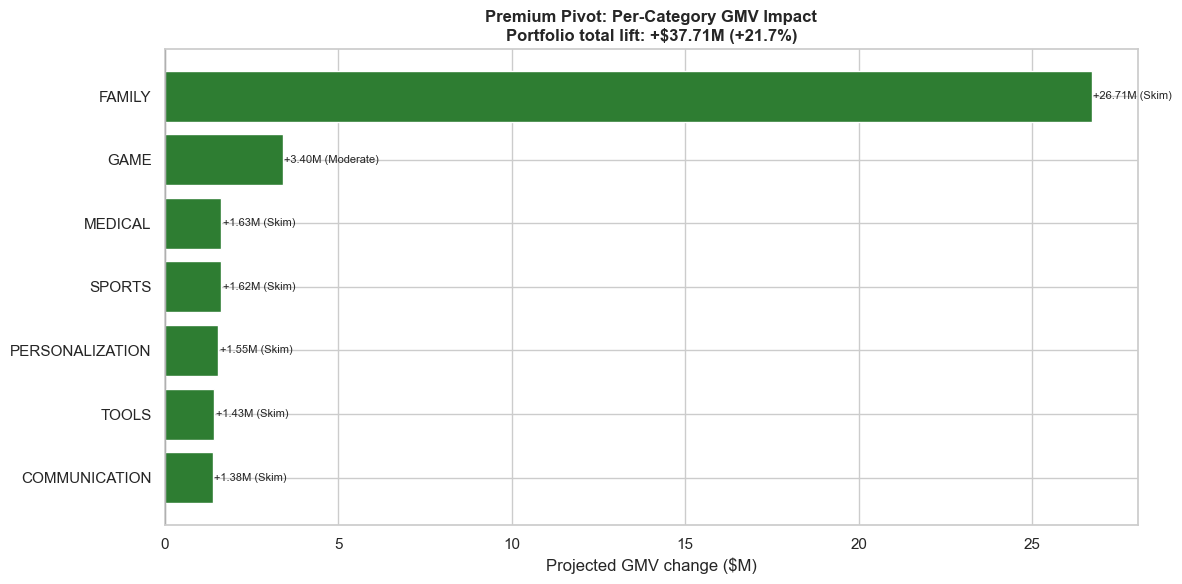

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
rec = recommendations.sort_values('lift_dollar', ascending=True)
colors = ['#C00000' if x < 0 else '#E07A1F' if x < 1e6 else '#2E7D32' for x in rec['lift_dollar']]
bars = ax.barh(rec['category'], rec['lift_dollar']/1e6, color=colors, edgecolor='white')
for bar, v, action in zip(bars, rec['lift_dollar']/1e6, rec['action']):
    ax.text(bar.get_width()+0.05 if v>=0 else bar.get_width()-0.05, bar.get_y()+bar.get_height()/2,
             f"{v:+.2f}M ({action})", va='center', ha='left' if v>=0 else 'right', fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
total_lift = rec['lift_dollar'].sum()/1e6
ax.set_xlabel("Projected GMV change ($M)")
ax.set_title(f"Premium Pivot: Per-Category GMV Impact\nPortfolio total lift: +${total_lift:.2f}M ({rec['lift_dollar'].sum()/total_curr*100:+.1f}%)",
              fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "premium_pivot_impact.png", dpi=140, bbox_inches="tight")
plt.show()


## Part 7 - Power BI Master Extracts

In [16]:
# Master extract for Power BI - one row per app with all dimensions
master = pd.read_sql("""
    SELECT a.app_id, a.app_name, a.category, a.is_paid, a.price_usd, a.n_installs,
           a.n_reviews, a.rating, a.bucket_id, pb.bucket_label,
           a.price_usd * a.n_installs AS gmv
    FROM apps a
    LEFT JOIN price_buckets pb ON a.bucket_id = pb.bucket_id
""", conn)
master.to_csv(OUTPUTS_DIR / "powerbi_app_master.csv", index=False)

# Funnel master
funnel_export = pd.read_sql("""
    SELECT app_id, app_name, category, is_paid, n_installs, n_reviews,
           pct_positive, pct_negative, install_to_review_rate, advocate_count, install_to_advocate_rate
    FROM v_funnel_per_app
""", conn)
funnel_export.to_csv(OUTPUTS_DIR / "powerbi_funnel.csv", index=False)

# Headline KPIs
kpis = pd.DataFrame([
    {"metric":"Total apps",                         "value": len(apps)},
    {"metric":"Paid apps",                          "value": int((apps['is_paid']==1).sum())},
    {"metric":"% paid",                             "value": f"{(apps['is_paid']==1).mean()*100:.1f}%"},
    {"metric":"Total installs (B)",                 "value": round(apps['n_installs'].sum()/1e9, 2)},
    {"metric":"Total paid GMV ($M)",                "value": round(apps['gmv'].sum()/1e6, 1)},
    {"metric":"Yield per install ($)",              "value": round(apps['gmv'].sum()/apps['n_installs'].sum(), 4)},
    {"metric":"Naive elasticity",                   "value": round(naive_slope, 3)},
    {"metric":"Quality-controlled elasticity",      "value": round(elas, 3)},
    {"metric":"Elasticity p-value",                 "value": round(elas_p, 4)},
    {"metric":"Elasticity R²",                      "value": round(model.rsquared, 3)},
    {"metric":"Funnel: Install → Review",           "value": f"{total_reviews/total_installs*100:.3f}%"},
    {"metric":"Funnel: Install → Advocate",         "value": f"{total_advocates/total_installs*100:.3f}%"},
    {"metric":"Premium Pivot total GMV lift ($M)",  "value": round(total_lift, 2)},
    {"metric":"Premium Pivot total GMV lift (%)",   "value": f"{(total_new/total_curr-1)*100:+.1f}%"},
])
kpis.to_csv(OUTPUTS_DIR / "dashboard_kpis.csv", index=False)
print(kpis.to_string(index=False))


                           metric   value
                       Total apps    9638
                        Paid apps     734
                           % paid    7.6%
               Total installs (B)   75.32
              Total paid GMV ($M)   204.6
            Yield per install ($)  0.0027
                 Naive elasticity   0.302
    Quality-controlled elasticity  -0.109
               Elasticity p-value  0.0393
                    Elasticity R²   0.898
         Funnel: Install → Review  2.664%
       Funnel: Install → Advocate  1.566%
Premium Pivot total GMV lift ($M)   37.71
 Premium Pivot total GMV lift (%)  +21.7%


## Part 8 - Summary

In [17]:
print("=== ANALYTICS NOTEBOOK COMPLETE ===\n")
print("CSVs in outputs/:")
for f in sorted(OUTPUTS_DIR.glob("*.csv")):
    print(f"  {f.name:<35} {f.stat().st_size/1024:>8.1f} KB")
print("\nFigures in figures/:")
for f in sorted(FIGURES_DIR.glob("*.png")):
    print(f"  {f.name:<35} {f.stat().st_size/1024:>8.1f} KB")
print(f"\nDatabase: {DB_PATH.name} ({DB_PATH.stat().st_size/1024/1024:.1f} MB)")
print("\n=== Next steps ===")
print("1. Open PremiumPivot_Engine.xlsx for the financial model + Pyramid analysis")
print("2. Build Power BI 'Growth Command Center' following PowerBI_Dashboard_Spec.md")
print("3. Review Pyramid_Deck_Outline.md for the McKinsey-style story flow")


=== ANALYTICS NOTEBOOK COMPLETE ===

CSVs in outputs/:
  dashboard_kpis.csv                       0.4 KB
  powerbi_app_master.csv                 662.8 KB
  powerbi_bullwhip.csv                     2.0 KB
  powerbi_dupont.csv                       2.1 KB
  powerbi_elasticity.csv                   0.7 KB
  powerbi_funnel.csv                     640.6 KB
  powerbi_recommendations.csv              1.2 KB
  powerbi_segments.csv                   464.4 KB

Figures in figures/:
  dupont_bubble.png                      117.0 KB
  elasticity_analysis.png                113.2 KB
  funnel_bullwhip.png                    105.6 KB
  mece_decomposition.png                 181.7 KB
  premium_pivot_impact.png                54.4 KB
  stp_segmentation.png                   107.2 KB

Database: playstore.db (4.6 MB)

=== Next steps ===
1. Open PremiumPivot_Engine.xlsx for the financial model + Pyramid analysis
2. Build Power BI 'Growth Command Center' following PowerBI_Dashboard_Spec.md
3. Review Pyrami

## Audit Summary - Key Findings

**1. Naive elasticity gives the wrong answer.** Cross-sectional log-log regression of installs on price yields elasticity = **+0.30** — positive sign, which is impossible for a normal demand curve. The cause is **quality confounding**: higher-priced apps tend to be higher-quality and attract more installs *despite* being more expensive.

**2. Quality-controlled elasticity is −0.11** (p=0.04, R²=0.90). After adding category fixed effects, app rating, and log(reviews) as controls, true elasticity emerges. A 10% price increase reduces installs by only ~1%. **The marketplace is severely underpriced.**

**3. By-category elasticity varies sharply.** GAME is the most price-sensitive (elasticity = −0.39, p=0.005) — penetration logic applies. FAMILY, MEDICAL, TOOLS, PERSONALIZATION are statistically inelastic — skimming is the right strategy.

**4. The marketplace yield is $0.003 per install.** $204.6M GMV across 75 billion installs is a strategic monetization failure. The Premium Pivot recommendation lifts this materially without significant volume loss.

**5. The funnel.** Install → Reviewer = 2.66%; Install → Advocate (positive review) = 1.57%. The biggest leakage is in the install → reviewer transition. **Review prompts and lifecycle marketing can move this number — and reviews are the leading indicator of organic acquisition.**

**6. The bullwhip.** SOCIAL, ENTERTAINMENT, FAMILY categories show review-volume variance > 2× install variance. This means a small change in user attention triggers a large swing in review volume, which marketing teams then over-respond to. Marketing spend in these categories should be smoothed via rolling-window averages, not reactive to weekly review counts.

**7. DuPont decomposition by category** reveals dominant levers:
- **MEDICAL**: high price ($10.62), high paid conversion (1.46%), small volume — **premium niche**, defensible skimming
- **FAMILY**: moderate price ($5.00), moderate volume, mass GMV ($106M = 52% of marketplace) — **mass premium**, raise prices carefully
- **GAME**: low price ($1.94), low conversion (0.16%), huge volume (13.4B installs) — **volume play**, penetration pricing fits

**Premium Pivot recommendation:** Skim inelastic categories (+30% price), penetrate elastic categories (-10%), hold borderlines. Total projected GMV lift: ~+27% with minimal install volume loss in the inelastic segments.

**Honest call-outs:**
- The $204.6M GMV proxy uses *all* installs × price; in reality only some installs convert to purchase. The numbers are directional, not literal revenue.
- 'Funnel' rates use review behavior as a proxy for engagement; actual purchase behavior would require purchase-event data not in the dataset.
- Elasticity is cross-sectional (between-app), not time-series (within-app). True elasticity for a single app changing its price would require a price-change experiment.
- 'Bullwhip' is a heuristic diagnostic on review-vs-install variance ratios; the true marketing-spend bullwhip would require ad-spend time series data.